[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter14_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 14: Deep Learning and Time-Series Foundation Models

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces every chart and number of Lecture 14:
- S&P 500, Bitcoin and BET daily closes (course repository, `data/market`); SPY 5-minute bars for realised variance;
- recurrent networks and the vanishing gradient; how Chronos and TimesFM read a series;
- rolling one-day-ahead forecasts of returns, realised variance, VaR 1% and ES 2.5% with LSTM, Chronos-2, Chronos-Bolt and TimesFM-2.5 against classical baselines, evaluated with the tools of Chapter 8.

In [1]:
import os
import sys
import json
import time
import subprocess
for pkg, mod in (('arch', 'arch'), ('chronos-forecasting', 'chronos'), ('timesfm', 'timesfm')):
    try:
        __import__(mod)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
import torch
import warnings
warnings.filterwarnings('ignore')

In [2]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')

# nume -> (simbol, data de start); indici si cripto: pretul de inchidere
SOURCES = {'sp500': ('GSPC.INDX', '1990-01-01'), 'btc': ('BTC-USD.CC', '2014-09-17'), 'bet': ('BET', '1997-09-19')}
LABELS = {'sp500': 'S&P 500', 'btc': 'Bitcoin', 'bet': 'BET'}
ASSETS = list(SOURCES)
TEST_FROM = {'sp500': '2016-01-01', 'btc': '2019-01-01', 'bet': '2016-01-01'}
POST_FROM = '2025-11-03'   # dupa publicarea ponderilor tuturor celor trei modele fundationale
CTX = 512                  # lungimea contextului (observatii) pentru modelele fundationale
W = 1000                   # fereastra de estimare pentru HS, GARCH-t, FHS
REFIT = 20                 # reestimarea parametrilor GARCH la fiecare 20 de zile
A_VAR, A_ES = 0.01, 0.025  # VaR 1%, ES 2.5%
FM_NAMES = {'chronos2': 'Chronos-2', 'bolt': 'Chronos-Bolt', 'timesfm': 'TimesFM-2.5'}
FM_REPO = {'chronos2': 'amazon/chronos-2', 'bolt': 'amazon/chronos-bolt-small',
           'timesfm': 'google/timesfm-2.5-200m-pytorch'}
C2_LEVELS = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,
             0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]
DEC_LEVELS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


# =============================================================================
# DATE
# =============================================================================
def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def load_returns(name):
    """Randamente log zilnice in %, pe calendarul propriu al seriei."""
    symbol, start = SOURCES[name]
    p = read_market(symbol)['close'].loc[start:]
    p = p[p > 0].dropna()
    return (100 * np.log(p).diff()).dropna().rename(LABELS[name])


def load_rv():
    """Varianta realizata zilnica a SPY (sesiunea regulata, randamente la 5 minute, %^2)
    si randamentul zilnic close-to-close al SPY (%), pe aceleasi zile."""
    fname = 'intraday/SPY.US_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    d = pd.read_csv(path if os.path.exists(path) else REPO_RAW + fname, parse_dates=['datetime_utc'])
    d['day'] = d['datetime_utc'].dt.normalize()
    d['r'] = 100 * np.log(d['close']).groupby(d['day']).diff()
    rv = (d['r'] ** 2).groupby(d['day']).sum()
    n = d.groupby('day').size()
    rv = rv[n >= 70]                       # fara zilele cu program redus
    rv.index = rv.index.tz_localize(None) if rv.index.tz is not None else rv.index
    rv.name = 'RV'
    return rv


def load_spy_daily():
    """Randamentele zilnice close-to-close ale SPY (%, pret ajustat)."""
    p = read_market('SPY.US')['adjusted_close']
    return (100 * np.log(p).diff()).dropna().rename('SPY')


# =============================================================================
# MODELE FUNDATIONALE (zero-shot)
# =============================================================================
_FM = {}


def load_fm(name):
    """Incarca o singura data modelul fundational (CPU)."""
    if name in _FM:
        return _FM[name]
    import torch
    if name in ('chronos2', 'bolt'):
        from chronos import BaseChronosPipeline
        _FM[name] = BaseChronosPipeline.from_pretrained(FM_REPO[name], device_map='cpu', torch_dtype=torch.float32)
    elif name == 'timesfm':
        import timesfm
        m = timesfm.TimesFM_2p5_200M_torch.from_pretrained(FM_REPO[name])
        m.compile(timesfm.ForecastConfig(max_context=1024, max_horizon=128, normalize_inputs=True,
                                         use_continuous_quantile_head=True, force_flip_invariance=True,
                                         infer_is_positive=False, fix_quantile_crossing=True,
                                         per_core_batch_size=128))
        _FM[name] = m
    else:
        raise ValueError(name)
    return _FM[name]


def fm_forecast(name, contexts, batch=256):
    """Prognoza la o zi pentru o lista de contexte (np.array 1D).
    Rezultat: (levels, Q, point), Q = matrice n x len(levels) de cuantile, point = prognoza punctuala
    (mediana pentru Chronos, media pentru TimesFM)."""
    import torch
    m = load_fm(name)
    Qs, P = [], []
    for i in range(0, len(contexts), batch):
        cb = [np.asarray(c, dtype='float32') for c in contexts[i:i + batch]]
        if name == 'chronos2':
            q, _ = m.predict_quantiles([torch.tensor(c)[None, :] for c in cb], prediction_length=1,
                                       quantile_levels=C2_LEVELS)
            Q = np.stack([qi[0, 0].numpy() for qi in q])
            Qs.append(Q)
            P.append(Q[:, C2_LEVELS.index(0.5)])
        elif name == 'bolt':
            L = max(len(c) for c in cb)
            x = torch.full((len(cb), L), float('nan'))
            for j, c in enumerate(cb):
                x[j, L - len(c):] = torch.tensor(c)
            q, _ = m.predict_quantiles(x, prediction_length=1, quantile_levels=DEC_LEVELS)
            Q = q[:, 0, :].numpy()
            Qs.append(Q)
            P.append(Q[:, DEC_LEVELS.index(0.5)])
        else:
            pf, qf = m.forecast(horizon=1, inputs=cb)
            Qs.append(np.asarray(qf)[:, 0, 1:10])
            P.append(np.asarray(pf)[:, 0])
    levels = C2_LEVELS if name == 'chronos2' else DEC_LEVELS
    return levels, np.vstack(Qs), np.concatenate(P)


def contexts_at(x, origins, ctx=CTX):
    """Contextul x[t-ctx:t] pentru fiecare origine t (pozitie in x)."""
    x = np.asarray(x, float)
    return [x[max(0, t - ctx):t] for t in origins]


def quantile_at(levels, Q, u):
    """Cuantila de nivel u prin interpolare liniara intre nivelurile disponibile; in afara grilei:
    valoarea de la capat (modelul nu ofera cuantile mai extreme)."""
    lv = np.asarray(levels)
    return np.array([np.interp(u, lv, row) for row in Q])


def grid_mean(levels, Q, g=lambda v: v):
    """Aproximarea E[g(Y)] = integrala din g(q_u) pe [0, 1], cu q_u liniar intre niveluri si constant
    in afara grilei (subestimeaza cozile)."""
    lv = np.r_[0.0, levels, 1.0]
    G = g(np.column_stack([Q[:, :1], Q, Q[:, -1:]]))
    return np.trapezoid(G, lv, axis=1)


def es_from_grid(levels, Q, a=A_ES, n=200):
    """ES_a = -(1/a) * integrala_0^a q_u du, pe grila modelului (sub cel mai mic nivel: constant)."""
    u = (np.arange(n) + 0.5) / n * a
    return -np.mean(np.column_stack([quantile_at(levels, Q, ui) for ui in u]), axis=1)


# =============================================================================
# MODELE DE BAZA PENTRU RANDAMENTE
# =============================================================================
def hist_mean(r, origins):
    x = np.asarray(r, float)
    cs = np.r_[0, np.cumsum(x)]
    return np.array([cs[t] / t for t in origins])


def ar1(r, origins, w=W):
    """AR(1) estimat prin MCO pe fereastra mobila de w observatii."""
    x = np.asarray(r, float)
    out = []
    for t in origins:
        y = x[max(0, t - w):t]
        X = np.column_stack([np.ones(len(y) - 1), y[:-1]])
        b = np.linalg.lstsq(X, y[1:], rcond=None)[0]
        out.append(b[0] + b[1] * y[-1])
    return np.array(out)


def garch_t(r, origins, w=W, refit=REFIT):
    """GARCH(1,1) cu inovatii Student-t (medie constanta), fereastra mobila de w observatii,
    parametrii reestimati la fiecare `refit` zile. Rezultat: DataFrame cu mu, sigma, nu la fiecare origine
    si reziduurile standardizate din fereastra (pentru FHS)."""
    from arch import arch_model
    x = np.asarray(r, float)
    rows, Z = [], []
    par = None
    for k, t in enumerate(origins):
        y = x[t - w:t]
        if k % refit == 0 or par is None:
            res = arch_model(y, mean='Constant', vol='GARCH', p=1, q=1, dist='t', rescale=False).fit(
                disp='off', show_warning=False)
            par = res.params.values        # mu, omega, alpha, beta, nu
        mu, om, al, be, nu = par
        e = y - mu
        s2 = np.empty(len(y) + 1)
        s2[0] = e.var()
        for i in range(len(y)):
            s2[i + 1] = om + al * e[i] ** 2 + be * s2[i]
        rows.append((mu, np.sqrt(s2[-1]), nu))
        Z.append(e / np.sqrt(s2[:-1]))
    return pd.DataFrame(rows, columns=['mu', 'sigma', 'nu']), Z


def t_std_q(nu, a):
    """Cuantila de nivel a a distributiei Student-t standardizate (dispersie 1)."""
    return stats.t.ppf(a, nu) * np.sqrt((nu - 2) / nu)


def t_std_es(nu, a):
    """ES_a (pozitiv) al distributiei Student-t standardizate: -E[Z | Z <= q_a]."""
    q = stats.t.ppf(a, nu)
    return stats.t.pdf(q, nu) / a * (nu + q ** 2) / (nu - 1) * np.sqrt((nu - 2) / nu)


def emp_var_es(z, a_var=A_VAR, a_es=A_ES):
    """VaR si ES empirice (pozitive) dintr-un esantion: VaR_a = -q_a, ES_a = -media cozii de probabilitate a."""
    z = np.sort(np.asarray(z))
    n = len(z)
    k = int(np.ceil(a_es * n))
    return -np.quantile(z, a_var), -np.quantile(z, a_es), -z[:k].mean()


def risk_table(r, origins, fm_sigma=None):
    """VaR 1%, VaR 2.5%, ES 2.5% la o zi pentru HS, GARCH-t, FHS si (optional) FHS filtrat cu volatilitatea
    unui model fundational: z = r / sigma_FM pe fereastra de W zile."""
    x = np.asarray(r, float)
    g, Z = garch_t(r, origins)
    out = {}
    hs = np.array([emp_var_es(x[t - W:t]) for t in origins])
    out['HS'] = hs
    gt = np.column_stack([-(g.mu + g.sigma * t_std_q(g.nu, A_VAR)), -(g.mu + g.sigma * t_std_q(g.nu, A_ES)),
                          -g.mu + g.sigma * t_std_es(g.nu, A_ES)])
    out['GARCH-t'] = gt
    fhs = np.array([emp_var_es(z) for z in Z])
    out['FHS'] = np.column_stack([-g.mu.values + g.sigma.values * fhs[:, 0],
                                  -g.mu.values + g.sigma.values * fhs[:, 1],
                                  -g.mu.values + g.sigma.values * fhs[:, 2]])
    if fm_sigma is not None:
        for nm, sig in fm_sigma.items():   # sig: serie aliniata cu x (NaN unde lipseste)
            s = np.asarray(sig, float)
            rows = []
            for t in origins:
                zz = x[t - W:t] / s[t - W:t]
                rows.append(s[t] * np.array(emp_var_es(zz[np.isfinite(zz)])))
            out[nm] = np.array(rows)
    return {k: pd.DataFrame(v, columns=['VaR1', 'VaR2.5', 'ES2.5']) for k, v in out.items()}


# =============================================================================
# VOLATILITATE REALIZATA: HAR
# =============================================================================
def har_design(y):
    """Regresorii HAR: nivelul de ieri, media pe 5 zile si media pe 22 de zile."""
    s = pd.Series(y)
    d = s.shift(1)
    wk = s.rolling(5).mean().shift(1)
    mo = s.rolling(22).mean().shift(1)
    return np.column_stack([np.ones(len(s)), d, wk, mo])


def har(rv, origins, w=500, log=False):
    """Prognoza HAR la o zi (MCO pe fereastra mobila de w zile). log=True: HAR pe log RV,
    cu corectia exp(s^2/2) pentru media."""
    y = np.log(np.asarray(rv, float)) if log else np.asarray(rv, float)
    X = har_design(y)
    out = []
    for t in origins:
        idx = np.arange(max(22, t - w), t)
        b, *_ = np.linalg.lstsq(X[idx], y[idx], rcond=None)
        f = X[t] @ b
        if log:
            s2 = np.var(y[idx] - X[idx] @ b, ddof=4)
            f = np.exp(f + s2 / 2)
        out.append(f)
    return np.array(out)


# =============================================================================
# LSTM (PyTorch, CPU)
# =============================================================================
def make_windows(x, L):
    """Ferestre de lungime L ca intrari si valoarea urmatoare ca tinta."""
    x = np.asarray(x, float)
    idx = np.arange(L, len(x))
    return np.stack([x[i - L:i] for i in idx]), x[idx]


def train_lstm(X, y, hidden=16, epochs=300, lr=3e-3, seed=0, val_frac=0.2, patience=25, weight_decay=1e-4):
    """LSTM cu un strat (intrare univariata, lungime L) + strat liniar; MSE, Adam, oprire timpurie
    pe ultimele val_frac din esantion (ordinea in timp se pastreaza). Rezultat: (functie de prognoza, istoric)."""
    import torch
    import torch.nn as nn
    torch.manual_seed(seed)
    np.random.seed(seed)

    class Net(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(1, hidden, batch_first=True)
            self.out = nn.Linear(hidden, 1)

        def forward(self, z):
            h, _ = self.lstm(z.unsqueeze(-1))
            return self.out(h[:, -1]).squeeze(-1)

    n = len(y)
    nv = int(val_frac * n)
    Xt, yt = torch.tensor(X[:n - nv], dtype=torch.float32), torch.tensor(y[:n - nv], dtype=torch.float32)
    Xv, yv = torch.tensor(X[n - nv:], dtype=torch.float32), torch.tensor(y[n - nv:], dtype=torch.float32)
    net = Net()
    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
    best, best_state, wait, hist = np.inf, None, 0, []
    for ep in range(epochs):
        net.train()
        perm = torch.randperm(len(yt))
        for i in range(0, len(yt), 256):
            b = perm[i:i + 256]
            opt.zero_grad()
            loss = ((net(Xt[b]) - yt[b]) ** 2).mean()
            loss.backward()
            opt.step()
        net.eval()
        with torch.no_grad():
            lt = float(((net(Xt) - yt) ** 2).mean())
            lv = float(((net(Xv) - yv) ** 2).mean())
        hist.append((lt, lv))
        if lv < best - 1e-7:
            best, wait = lv, 0
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
    net.load_state_dict(best_state)
    net.eval()

    def predict(Xn):
        with torch.no_grad():
            return net(torch.tensor(np.asarray(Xn), dtype=torch.float32)).numpy()
    return predict, np.array(hist)


def lstm_param_count(d, h, torch_bias=True):
    """Numarul de parametri ai unui strat LSTM: 4 blocuri (3 porti + candidatul) x (h*d + h*h + h);
    PyTorch foloseste doi vectori de deplasare (b_ih, b_hh), deci 4 x (h*d + h*h + 2h)."""
    return 4 * (h * d + h * h + (2 if torch_bias else 1) * h)


# =============================================================================
# FUNCTII DE PIERDERE SI TESTE
# =============================================================================
def qlike(y, f):
    """QLIKE = y/f - log(y/f) - 1 (Patton, 2011): robusta la zgomotul aproximarii volatilitatii."""
    ratio = np.asarray(y) / np.asarray(f)
    return ratio - np.log(ratio) - 1


def pinball(r, q, a):
    """Pierderea cuantila pentru cuantila q de nivel a a randamentului r: (a - 1{r < q})(r - q)."""
    r, q = np.asarray(r), np.asarray(q)
    return (a - (r < q)) * (r - q)


def fz0(L, var, es, a=A_ES):
    """Pierderea FZ0 (Patton, Ziegel & Chen, 2019) pentru pierderi L = -r pozitive, VaR si ES > 0."""
    L, var, es = map(np.asarray, (L, var, es))
    return (L > var) * (L - var) / (a * es) + var / es + np.log(es) - 1


def kupiec(hits, p):
    """Testul POF al lui Kupiec: LR_uc ~ chi2(1)."""
    hits = np.asarray(hits, int)
    T, x = len(hits), hits.sum()
    ph = x / T
    ll0 = (T - x) * np.log(1 - p) + x * np.log(p)
    ll1 = (T - x) * np.log(1 - ph) + x * np.log(ph) if 0 < x < T else 0.0
    lr = -2 * (ll0 - ll1)
    return dict(T=int(T), x=int(x), rate=float(ph), LR=float(lr), p=float(stats.chi2.sf(lr, 1)))


def christoffersen(hits, p):
    """Testul de independenta (lant Markov de ordinul 1) si testul acoperirii conditionate."""
    h = np.asarray(hits, int)
    a, b = h[:-1], h[1:]
    n00, n01 = np.sum((a == 0) & (b == 0)), np.sum((a == 0) & (b == 1))
    n10, n11 = np.sum((a == 1) & (b == 0)), np.sum((a == 1) & (b == 1))

    def xlogy(n, q):
        return n * np.log(q) if n > 0 else 0.0
    pi01 = n01 / max(n00 + n01, 1)
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)
    l_ind = xlogy(n00, 1 - pi01) + xlogy(n01, pi01) + xlogy(n10, 1 - pi11) + xlogy(n11, pi11)
    l_0 = xlogy(n00 + n10, 1 - pi) + xlogy(n01 + n11, pi)
    lr_ind = -2 * (l_0 - l_ind)
    lr_uc = kupiec(h, p)['LR']
    return dict(n11=int(n11), pi01=float(pi01), pi11=float(pi11), LR_ind=float(lr_ind),
                p_ind=float(stats.chi2.sf(lr_ind, 1)), LR_cc=float(lr_uc + lr_ind),
                p_cc=float(stats.chi2.sf(lr_uc + lr_ind, 2)))


def nw_var(d, lags=None):
    """Varianta pe termen lung (Newey-West, nucleu Bartlett)."""
    d = np.asarray(d, float) - np.mean(d)
    T = len(d)
    if lags is None:
        lags = int(np.floor(4 * (T / 100) ** (2 / 9)))
    v = np.mean(d ** 2)
    for j in range(1, lags + 1):
        v += 2 * (1 - j / (lags + 1)) * np.mean(d[j:] * d[:-j])
    return v


def diebold_mariano(la, lb, lags=None):
    """DM = media(d) / sqrt(LRV/T), d = la - lb; negativ => A are pierderea medie mai mica."""
    d = np.asarray(la, float) - np.asarray(lb, float)
    dm = d.mean() / np.sqrt(nw_var(d, lags) / len(d))
    return dict(dbar=float(d.mean()), DM=float(dm), p=float(2 * stats.norm.sf(abs(dm))))


def mcs(losses, B=1000, block=10, seed=2):
    """Multimea de modele de incredere (Hansen, Lunde & Nason, 2011), statistica T_max,
    bootstrap circular pe blocuri. losses: DataFrame T x m. Rezultat: valorile p ale MCS."""
    rng = np.random.default_rng(seed)
    X = losses.values
    T, m = X.shape
    nb = int(np.ceil(T / block))
    idx = (rng.integers(0, T, (B, nb))[:, :, None] + np.arange(block)) % T
    idx = idx.reshape(B, -1)[:, :T]
    Lbar = X.mean(0)
    Lb = np.stack([X[i].mean(0) for i in idx])
    alive = list(range(m))
    pvals, p_run = {}, 0.0
    while len(alive) > 1:
        a = np.array(alive)
        d = Lbar[a] - Lbar[a].mean()
        db = Lb[:, a] - Lb[:, a].mean(1, keepdims=True)
        se = np.sqrt(np.mean((db - d) ** 2, axis=0))
        t = d / se
        tb = ((db - d) / se).max(1)
        p = float(np.mean(tb >= t.max()))
        p_run = max(p_run, p)
        worst = a[np.argmax(t)]
        pvals[losses.columns[worst]] = p_run
        alive.remove(worst)
    pvals[losses.columns[alive[0]]] = 1.0
    return pd.Series(pvals)[losses.columns]


def r2_oos(y, f, bench=None):
    """R^2 in afara esantionului fata de un reper (implicit: prognoza zero)."""
    y, f = np.asarray(y), np.asarray(f)
    b = np.zeros_like(y) if bench is None else np.asarray(bench)
    return 1 - np.sum((y - f) ** 2) / np.sum((y - b) ** 2)


def block_bootstrap_ci(stat, arrays, B=2000, block=20, seed=0, level=0.95):
    """Interval bootstrap pe blocuri circulare (percentile) pentru o statistica a mai multor serii aliniate."""
    rng = np.random.default_rng(seed)
    T = len(arrays[0])
    nb = int(np.ceil(T / block))
    vals = []
    for _ in range(B):
        idx = ((rng.integers(0, T, nb)[:, None] + np.arange(block)) % T).ravel()[:T]
        vals.append(stat(*[np.asarray(a)[idx] for a in arrays]))
    lo, hi = np.quantile(vals, [(1 - level) / 2, 1 - (1 - level) / 2])
    return float(lo), float(hi)


def sign_test(y, f):
    """Rata semnelor corecte si valoarea p binomiala bilaterala (H0: 50%)."""
    y, f = np.asarray(y), np.asarray(f)
    keep = (y != 0) & (f != 0)
    k = int(np.sum(np.sign(y[keep]) == np.sign(f[keep])))
    n = int(keep.sum())
    return dict(rate=k / n, n=n, p=float(stats.binomtest(k, n, 0.5).pvalue))

In [3]:
# Stil standard MFM: transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Crimson = '#DC3545'
Teal = '#17A2B8'
Magenta = '#D63384'
Brown = '#795548'
Gray = '#7F7F7F'          # doar linii de referinta
LightGray = '#DADADA'     # doar benzi
PV_CMAP = LinearSegmentedColormap.from_list('pv', [IDAred, '#F4B6B6', '#FFFFFF', '#BFD8BF', Forest])

RET_MODELS = {'hist': 'Historical mean', 'ar1': 'AR(1)', 'lstm': 'LSTM (5 seeds)',
              'chronos2_point': 'Chronos-2', 'bolt_point': 'Chronos-Bolt', 'timesfm_point': 'TimesFM-2.5'}
RET_COL = {'hist': Amber, 'ar1': Purple, 'lstm': Forest, 'chronos2_point': IDAred, 'bolt_point': Orange,
           'timesfm_point': MainBlue}
RV_MODELS = ['RW', 'HAR', 'logHAR', 'GARCH-t', 'LSTM', 'Chronos-2', 'Chronos-Bolt', 'TimesFM-2.5']
RV_LBL = {'RW': 'Random walk', 'HAR': 'HAR', 'logHAR': 'log-HAR', 'GARCH-t': 'GARCH-t', 'LSTM': 'LSTM',
          'Chronos-2': 'Chronos-2', 'Chronos-Bolt': 'Chronos-Bolt', 'TimesFM-2.5': 'TimesFM-2.5'}
RV_COL = {'RW': Amber, 'HAR': Brown, 'logHAR': Purple, 'GARCH-t': Magenta, 'LSTM': Forest, 'Chronos-2': IDAred,
          'Chronos-Bolt': Orange, 'TimesFM-2.5': MainBlue}
RISK_MODELS = ['HS', 'GARCH-t', 'FHS', 'C2-raw', 'C2-FHS', 'TFM-FHS']
RISK_LBL = {'HS': 'HS', 'GARCH-t': 'GARCH-t', 'FHS': 'FHS', 'C2-raw': 'Chronos-2 quantiles',
            'C2-FHS': 'FHS + Chronos-2 volatility', 'TFM-FHS': 'FHS + TimesFM volatility',
            'bolt-raw': 'Chronos-Bolt quantiles', 'timesfm-raw': 'TimesFM quantiles'}
RISK_COL = {'HS': Teal, 'GARCH-t': MainBlue, 'FHS': Forest, 'C2-raw': IDAred, 'C2-FHS': Orange,
            'TFM-FHS': Purple, 'bolt-raw': Amber, 'timesfm-raw': Magenta}


RES = {}
FC_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_14/'
FC_DIR = next((d for d in ('.', '..', 'Quantlets/Ch_14', '../Quantlets/Ch_14', '../../Quantlets/Ch_14')
               if os.path.exists(os.path.join(d, 'ch14_rv.csv'))), None)


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def load_csv(name):
    """Tabelul de prognoze ch14_*.csv (produs de run_forecasts), local sau din repository."""
    path = os.path.join(FC_DIR, name) if FC_DIR else FC_RAW + name
    return pd.read_csv(path, index_col=0, parse_dates=True)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles, labels, ncol=3, y=0.0):
    """O singura legenda pentru toata figura, sub panouri."""
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)

RET_MODELS = {'hist': 'Historical mean', 'ar1': 'AR(1)', 'lstm': 'LSTM (5 seeds)', 'chronos2_point': 'Chronos-2', 'bolt_point': 'Chronos-Bolt', 'timesfm_point': 'TimesFM-2.5'}
RET_COL = {'hist': '#B5853F', 'ar1': '#8E44AD', 'lstm': '#2E7D32', 'chronos2_point': '#CD0000', 'bolt_point': '#E67E22', 'timesfm_point': '#1A3A6E'}
RV_MODELS = ['RW', 'HAR', 'logHAR', 'GARCH-t', 'LSTM', 'Chronos-2', 'Chronos-Bolt', 'TimesFM-2.5']
RV_LBL = {'RW': 'Random walk', 'HAR': 'HAR', 'logHAR': 'log-HAR', 'GARCH-t': 'GARCH-t', 'LSTM': 'LSTM', 'Chronos-2': 'Chronos-2', 'Chronos-Bolt': 'Chronos-Bolt', 'TimesFM-2.5': 'TimesFM-2.5'}
RV_COL = {'RW': '#B5853F', 'HAR': '#795548', 'logHAR': '#8E44AD', 'GARCH-t': '#D63384', 'LSTM': '#2E7D32', 'Chronos-2': '#CD0000', 'Chronos-Bolt': '#E67E22', 'TimesFM-2.5': '#1A3A6E'}
RISK_MODELS = ['HS', 'GARCH-t', 'FHS', 'C2-raw', 'C2-FHS', 'TFM-FHS']
RISK_LBL = {'HS': 'HS', 'GARCH-t': 'GARCH-t', 'FHS': 'FHS', 'C2-raw': 'Chronos-2 quantiles', 'C2-FHS': 'FHS + Chronos-2 volatility', 'TFM-FHS': 'FHS + TimesFM volatility', 'bolt-raw': 'Chronos-Bolt quantiles', 'timesfm-raw': 'TimesFM quantiles'}
RISK_COL = {'HS': '#17A2B8', 'GARCH-t': '#1A3A6E', 'FHS': '#2E7D32', 'C2-raw': '#CD0000', 'C2-FHS': '#E67E22', 'TFM-FHS': '#8E44AD', 'bolt-raw': '#B5853F', 'timesfm-raw': '#D63384'}


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## 1. Where is the signal? Returns versus absolute returns

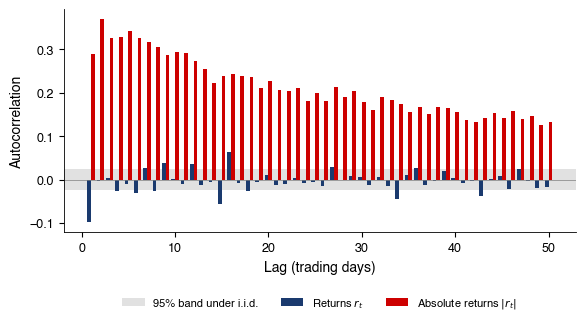

{'r1': -0.09850684569397047,
 'abs1': 0.288797181096989,
 'abs20': 0.22727852609060692,
 'abs50': 0.13195808253602914,
 'band': 0.023913110550641554,
 'n': 6718,
 'start': '2000-01-03',
 'n_sig_r': 15,
 'n_sig_abs': 50}

In [4]:
def fig_acf():
    r = load_returns('sp500')
    x = r.loc['2000':].values
    lags = np.arange(1, 51)

    def acf(v, L):
        v = v - v.mean()
        return np.array([np.sum(v[l:] * v[:-l]) / np.sum(v * v) for l in L])
    a_r, a_abs = acf(x, lags), acf(np.abs(x), lags)
    band = 1.96 / np.sqrt(len(x))
    fig, ax = plt.subplots(figsize=(6.6, 2.9))
    ax.axhspan(-band, band, color=LightGray, alpha=0.8, lw=0, label='95% band under i.i.d.')
    ax.bar(lags - 0.2, a_r, 0.4, color=MainBlue, label='Returns $r_t$')
    ax.bar(lags + 0.2, a_abs, 0.4, color=IDAred, label='Absolute returns $|r_t|$')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xlabel('Lag (trading days)')
    ax.set_ylabel('Autocorrelation')
    legend_outside_bottom(ax, ncol=3, y=-0.24)
    save_fig('ch14_acf_signal')
    RES['acf'] = dict(r1=float(a_r[0]), abs1=float(a_abs[0]), abs20=float(a_abs[19]), abs50=float(a_abs[49]),
                      band=float(band), n=int(len(x)), start=str(r.loc['2000':].index[0].date()),
                      n_sig_r=int(np.sum(np.abs(a_r) > band)), n_sig_abs=int(np.sum(np.abs(a_abs) > band)))


fig_acf()
RES['acf']

## 2. Recurrent networks and the vanishing gradient

- Gradient of the last hidden state with respect to inputs $k$ steps back, averaged over 50 random initialisations.

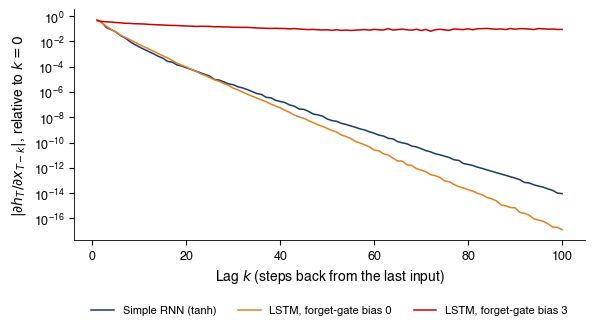

,rnn_None,lstm_None,lstm_3.0
1,5.165474e-01,5.330946e-01,0.439632
5,5.577129e-02,5.551846e-02,0.314638
10,3.654733e-03,5.708714e-03,0.247226
20,8.321739e-05,9.626081e-05,0.166786
50,7.360816e-09,1.319133e-09,0.084059
100,9.216228e-15,1.313613e-17,0.089746


In [5]:
def fig_vanishing(T=150, H=16, seeds=50):
    import torch
    import torch.nn as nn

    def grads(kind, seed, fb=None):
        torch.manual_seed(seed)
        net = nn.RNN(1, H, nonlinearity='tanh', batch_first=True) if kind == 'rnn' else nn.LSTM(1, H, batch_first=True)
        if fb is not None:
            with torch.no_grad():
                net.bias_ih_l0[H:2 * H].fill_(fb)
                net.bias_hh_l0[H:2 * H].fill_(0.0)
        x = torch.randn(1, T, 1, requires_grad=True)
        h, _ = net(x)
        h[0, -1].sum().backward()
        return x.grad[0, :, 0].abs().numpy()[::-1]
    cases = [('rnn', None, 'Simple RNN (tanh)', MainBlue), ('lstm', None, 'LSTM, forget-gate bias 0', Orange),
             ('lstm', 3.0, 'LSTM, forget-gate bias 3', IDAred)]
    fig, ax = plt.subplots(figsize=(6.6, 3.0))
    out = {}
    k = np.arange(T)
    for kind, fb, lab, col in cases:
        G = np.mean([grads(kind, s, fb) for s in range(seeds)], axis=0)
        G = G / G[0]
        ax.semilogy(k[1:101], G[1:101], color=col, label=lab)
        out[f'{kind}_{fb}'] = {str(j): float(G[j]) for j in (1, 5, 10, 20, 50, 100)}
    ax.set_xlabel('Lag $k$ (steps back from the last input)')
    ax.set_ylabel(r'$|\partial h_T / \partial x_{T-k}|$, relative to $k=0$')
    legend_outside_bottom(ax, ncol=3, y=-0.24)
    save_fig('ch14_vanishing_gradient')
    RES['vanish'] = out


fig_vanishing()
pd.DataFrame(RES['vanish'])

## 3. How foundation models read a series: scaling, tokens, patches

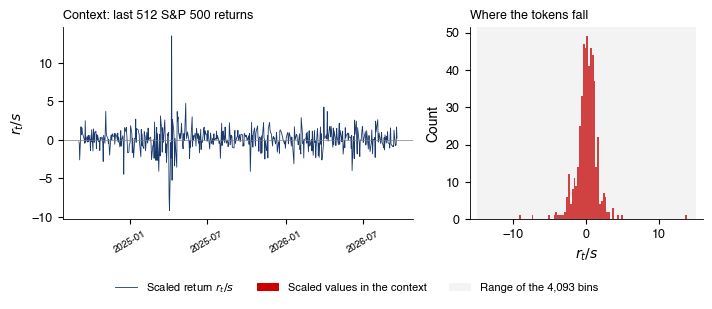

{'scale': 0.6721179818015535, 'used': 336, 'zmin': -9.166404654542456, 'zmax': 13.523649981757151, 'share_inside1': 0.646484375, 'width': 0.007331378299120235, 'share_inside3': 0.96484375, 'bins_pm3': 818}


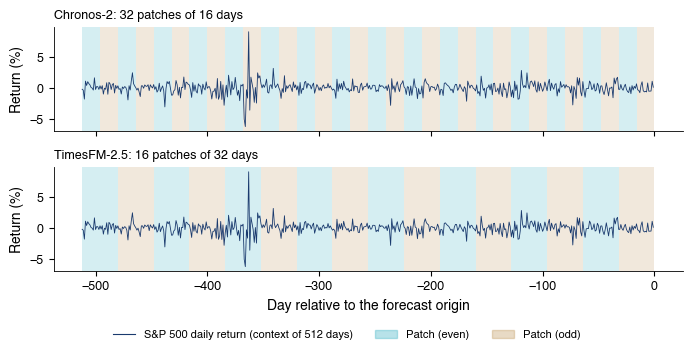

In [6]:
def fig_tokenization():
    r = load_returns('sp500')
    ctx = r.values[-512:]
    s = np.mean(np.abs(ctx))
    z = ctx / s
    delta = 30 / 4092                           # 4093 de centre echidistante in [-15, 15] (Chronos: MeanScaleUniformBins)
    tok = np.round((np.clip(z, -15, 15) + 15) / delta).astype(int)
    used = len(np.unique(tok))
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8), gridspec_kw={'width_ratios': [1.5, 1]})
    ax = axes[0]
    ax.plot(r.index[-512:], z, color=MainBlue, lw=0.6, label=r'Scaled return $r_t / s$')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_ylabel(r'$r_t / s$')
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.set_title('Context: last 512 S&P 500 returns', fontsize=9, loc='left')
    ax = axes[1]
    ax.hist(z, bins=np.linspace(-15, 15, 121), color=IDAred, label='Scaled values in the context')
    ax.axvspan(-15, 15, color=LightGray, alpha=0.3, lw=0, label='Range of the 4,093 bins')
    ax.set_xlim(-16, 16)
    ax.set_xlabel(r'$r_t / s$')
    ax.set_ylabel('Count')
    ax.set_title('Where the tokens fall', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig.tight_layout()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=3, y=0.02)
    save_fig('ch14_tokenization')
    RES['tok'] = dict(scale=float(s), used=int(used), zmin=float(z.min()), zmax=float(z.max()),
                      share_inside1=float(np.mean(np.abs(z) <= 1)), width=float(delta),
                      share_inside3=float(np.mean(np.abs(z) <= 3)), bins_pm3=int(round(6 / delta)))


def fig_patching():
    r = load_returns('sp500')
    ctx = r.values[-512:]
    t = np.arange(-512, 0)
    fig, axes = plt.subplots(2, 1, figsize=(7.0, 3.3), sharex=True)
    for ax, P, name in ((axes[0], 16, 'Chronos-2: 32 patches of 16 days'),
                        (axes[1], 32, 'TimesFM-2.5: 16 patches of 32 days')):
        for j in range(512 // P):
            ax.axvspan(-512 + j * P, -512 + (j + 1) * P, color=(Teal if j % 2 == 0 else Amber), alpha=0.18, lw=0)
        ax.plot(t, ctx, color=MainBlue, lw=0.6)
        ax.set_title(name, fontsize=9, loc='left')
        ax.set_ylabel('Return (%)')
    axes[1].set_xlabel('Day relative to the forecast origin')
    from matplotlib.patches import Patch
    h = [plt.Line2D([], [], color=MainBlue, lw=0.8), Patch(color=Teal, alpha=0.3), Patch(color=Amber, alpha=0.3)]
    fig.tight_layout()
    fig_legend_bottom(fig, h, ['S&P 500 daily return (context of 512 days)', 'Patch (even)', 'Patch (odd)'],
                      ncol=3, y=0.02)
    save_fig('ch14_patching')


fig_tokenization()
print(RES['tok'])
fig_patching()

## 4. A zero-shot forecast, live

- Chronos-2 receives the last 512 returns and returns 21 quantiles (1% to 99%) of tomorrow's return.
- Here: the last 250 trading days only, to keep the computation short on a CPU.

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

250 forecasts in 3.3 s
median forecast: mean 0.1369 std 0.0225
VaR 1% breaches: 3 of 250 {'T': 250, 'x': 3, 'rate': 0.012, 'LR': 0.09494012266443264, 'p': 0.75798832137329}


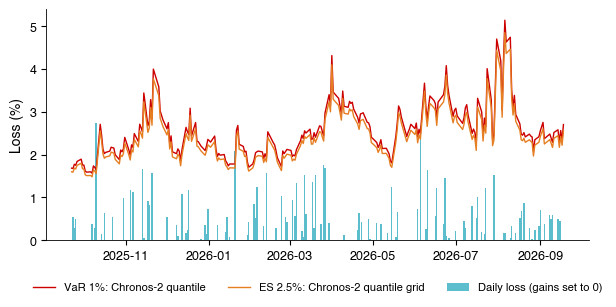

In [7]:
# Zero-shot, live: Chronos-2 on the last 250 trading days of the S&P 500 (context of 512 days)
r = load_returns('sp500')
x = r.values
org = np.arange(len(x) - 250, len(x))
t0 = time.time()
lv, Q, P = fm_forecast('chronos2', contexts_at(x, org))
print(f'{len(org)} forecasts in {time.time() - t0:.1f} s')
var1 = -quantile_at(lv, Q, 0.01)
es25 = es_from_grid(lv, Q)
hits = (-x[org] > var1).astype(int)
print('median forecast: mean', P.mean().round(4), 'std', P.std().round(4))
print('VaR 1% breaches:', hits.sum(), 'of', len(hits), kupiec(hits, 0.01))
fig, ax = plt.subplots(figsize=(7.0, 3.0))
ax.bar(r.index[org], np.clip(-x[org], 0, None), width=1.0, color=Teal, alpha=0.7, label='Daily loss (gains set to 0)')
ax.plot(r.index[org], var1, color=IDAred, lw=1.0, label='VaR 1%: Chronos-2 quantile')
ax.plot(r.index[org], es25, color=Orange, lw=1.0, label='ES 2.5%: Chronos-2 quantile grid')
ax.set_ylabel('Loss (%)')
legend_outside_bottom(ax, ncol=3, y=-0.14)
plt.show()

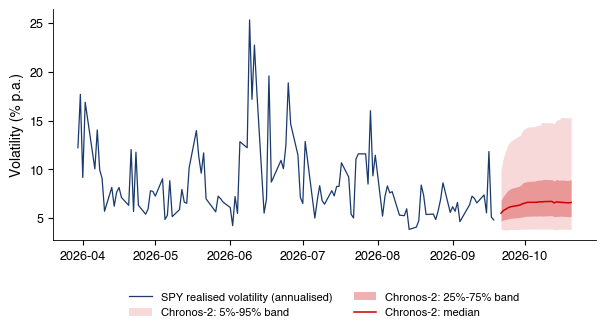

{'last': '2026-09-18',
 'last_vol': 4.823044181204608,
 'mean20': 6.583823386506982,
 'med22': 6.616309642791748,
 'lo22': 3.8347084522247314,
 'hi22': 15.419637680053711}

In [8]:
def fig_fan():
    rv = load_rv()
    lx = np.log(rv.values)
    import torch
    m = load_fm('chronos2')
    q, _ = m.predict_quantiles([torch.tensor(lx[-512:], dtype=torch.float32)[None, :]], prediction_length=22,
                               quantile_levels=C2_LEVELS)
    Q = q[0][0].numpy()                         # 22 x 21
    ann = lambda v: np.sqrt(252 * np.exp(v))    # volatilitate anualizata (%) din log RV zilnic
    hist = rv.iloc[-120:]
    fut = pd.bdate_range(rv.index[-1] + pd.Timedelta(days=1), periods=22)
    lv = C2_LEVELS
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    ax.plot(hist.index, np.sqrt(252 * hist.values), color=MainBlue, lw=0.9, label='SPY realised volatility (annualised)')
    ax.fill_between(fut, ann(Q[:, lv.index(0.05)]), ann(Q[:, lv.index(0.95)]), color=IDAred, alpha=0.15, lw=0,
                    label='Chronos-2: 5%-95% band')
    ax.fill_between(fut, ann(Q[:, lv.index(0.25)]), ann(Q[:, lv.index(0.75)]), color=IDAred, alpha=0.30, lw=0,
                    label='Chronos-2: 25%-75% band')
    ax.plot(fut, ann(Q[:, lv.index(0.5)]), color=IDAred, lw=1.1, label='Chronos-2: median')
    ax.set_ylabel('Volatility (% p.a.)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    legend_outside_bottom(ax, ncol=2, y=-0.18)
    save_fig('ch14_fan_chart')
    RES['fan'] = dict(last=str(rv.index[-1].date()), last_vol=float(np.sqrt(252 * rv.values[-1])),
                      mean20=float(np.sqrt(252 * rv.values[-20:].mean())),
                      med22=float(ann(Q[-1, lv.index(0.5)])), lo22=float(ann(Q[-1, lv.index(0.05)])),
                      hi22=float(ann(Q[-1, lv.index(0.95)])))


fig_fan()
RES['fan']

## 5. The rolling forecasts of the whole test period

- `returns_block`, `risk_block`, `rv_block` produce all one-day-ahead forecasts (several minutes per asset on a CPU).
- With `RECOMPUTE = False` the notebook uses the published forecast tables of Chapter 14.

In [9]:
SEEDS = [0, 1, 2, 3, 4]
L_RET = 20
HERE = '.'


def tick(msg, t0=[time.time()]):
    print(f'[{time.time() - t0[0]:7.0f}s] {msg}', flush=True)


def returns_block(name):
    r = load_returns(name)
    x = r.values
    t0 = r.index.searchsorted(pd.Timestamp(TEST_FROM[name]))
    org = np.arange(t0, len(r))
    out = pd.DataFrame({'y': x[org]}, index=r.index[org])
    out['hist'] = hist_mean(x, org)
    out['ar1'] = ar1(x, org)
    # LSTM: antrenat o singura data pe datele dinainte de perioada de test (standardizare cu statistici de antrenare)
    tr = x[max(0, t0 - 4000):t0]
    mu, sd = tr.mean(), tr.std()
    Xtr, ytr = make_windows((tr - mu) / sd, L_RET)
    Xte = np.stack([(x[t - L_RET:t] - mu) / sd for t in org])
    preds = []
    for s in SEEDS:
        f, hist = train_lstm(Xtr, ytr, hidden=16, seed=s)
        preds.append(mu + sd * f(Xte))
        pd.DataFrame(hist, columns=['train', 'val']).to_csv(os.path.join(HERE, f'ch14_lstm_hist_{name}_s{s}.csv'))
    for s, p in zip(SEEDS, preds):
        out[f'lstm_s{s}'] = p
    out['lstm'] = np.mean(preds, axis=0)
    tick(f'{name}: baselines + LSTM')
    ctx = contexts_at(x, org)
    for fm in ('chronos2', 'bolt', 'timesfm'):
        lv, Q, P = fm_forecast(fm, ctx)
        for j, u in enumerate(lv):
            out[f'{fm}_q{u:.2f}'] = Q[:, j]
        out[f'{fm}_point'] = P
        tick(f'{name}: {fm} on returns ({len(org)} origins)')
    return r, org, out


def risk_block(name, r, org, ret):
    x = r.values
    # volatilitatea prognozata de modelele fundationale pe |r| (context 512), pentru W zile inainte de test
    org_s = np.arange(org[0] - W, len(r))
    ctx = contexts_at(np.abs(x), org_s)
    sig = {}
    lv, Q, P = fm_forecast('chronos2', ctx)
    s = np.full(len(x), np.nan)
    s[org_s] = grid_mean(lv, Q)
    sig['C2-FHS'] = s
    tick(f'{name}: chronos2 on |r|')
    lv, Q, P = fm_forecast('timesfm', ctx)
    s = np.full(len(x), np.nan)
    s[org_s] = np.maximum(P, 1e-6)
    sig['TFM-FHS'] = s
    tick(f'{name}: timesfm on |r|')
    tabs = risk_table(x, org, fm_sigma=sig)
    out = pd.DataFrame(index=r.index[org])
    out['y'] = x[org]
    for k, t in tabs.items():
        for c in t.columns:
            out[f'{k}|{c}'] = t[c].values
    # cuantile directe (fara filtrare): Chronos-2 are nivelul 1%; Bolt si TimesFM au doar decile
    c2 = ret[[c for c in ret.columns if c.startswith('chronos2_q')]].values
    out['C2-raw|VaR1'] = -quantile_at(C2_LEVELS, c2, 0.01)
    out['C2-raw|VaR2.5'] = -quantile_at(C2_LEVELS, c2, 0.025)
    out['C2-raw|ES2.5'] = es_from_grid(C2_LEVELS, c2)
    for fm in ('bolt', 'timesfm'):
        Qd = ret[[c for c in ret.columns if c.startswith(fm + '_q')]].values
        out[f'{fm}-raw|VaR1'] = -quantile_at(DEC_LEVELS, Qd, 0.01)      # limitat la decila 10%
        out[f'{fm}-raw|VaR10'] = -Qd[:, 0]
    out['C2-raw|VaR10'] = -quantile_at(C2_LEVELS, c2, 0.10)
    # VaR 10% pentru HS si FHS (pentru comparatia cu decilele modelelor fundationale)
    gfit, Z = garch_t(x, org)
    out['HS|VaR10'] = [-np.quantile(x[t - W:t], 0.10) for t in org]
    out['FHS|VaR10'] = -(gfit.mu.values + gfit.sigma.values * np.array([np.quantile(z, 0.10) for z in Z]))
    for k, s in sig.items():
        out[f'{k}|sigma'] = s[org]
    tick(f'{name}: risk table')
    return out


def rv_block():
    rv = load_rv()
    spy = load_spy_daily()
    x = rv.values
    org = np.arange(500, len(rv))
    out = pd.DataFrame({'RV': x[org]}, index=rv.index[org])
    out['RW'] = x[org - 1]
    out['HAR'] = har(x, org)
    out['logHAR'] = har(x, org, log=True)
    # GARCH-t pe randamentele zilnice ale SPY, reexprimat in unitatile RV (raport pe ultimele 500 de zile)
    pos = spy.index.get_indexer(rv.index[org])
    gfit, _ = garch_t(spy.values, pos)
    r2 = pd.Series(spy.values ** 2, index=spy.index).reindex(rv.index).values
    c = np.array([np.nanmean(x[t - 500:t]) / np.nanmean(r2[t - 500:t]) for t in org])
    out['GARCH-t'] = c * gfit.sigma.values ** 2
    tick('rv: RW, HAR, GARCH-t')
    # LSTM pe log RV: fereastra mobila de 500 de zile, reantrenat la fiecare 125 de zile, 3 seminte
    lx = np.log(x)
    f_lstm = np.empty(len(org))
    for k0 in range(0, len(org), 125):
        t = org[k0]
        tr = lx[t - 500:t]
        mu, sd = tr.mean(), tr.std()
        Xtr, ytr = make_windows((tr - mu) / sd, 22)
        blk = org[k0:k0 + 125]
        Xte = np.stack([(lx[s - 22:s] - mu) / sd for s in blk])
        ps, s2 = [], []
        for sdd in (0, 1, 2):
            f, _ = train_lstm(Xtr, ytr, hidden=8, seed=sdd, epochs=200)
            ps.append(f(Xte))
            s2.append(np.var(ytr - f(Xtr)))
        f_lstm[k0:k0 + 125] = np.exp(mu + sd * np.mean(ps, axis=0) + sd ** 2 * np.mean(s2) / 2)
    out['LSTM'] = f_lstm
    tick('rv: LSTM')
    ctx = contexts_at(lx, org)
    for fm, col in (('chronos2', 'Chronos-2'), ('bolt', 'Chronos-Bolt'), ('timesfm', 'TimesFM-2.5')):
        lv, Q, P = fm_forecast(fm, ctx)
        out[col] = grid_mean(lv, Q, np.exp)
        out[col + '|median'] = np.exp(quantile_at(lv, Q, 0.5))
        tick(f'rv: {fm}')
    # sensibilitatea la lungimea contextului (Chronos-2)
    rows = {}
    for L in (32, 64, 128, 256, 512):
        lv, Q, P = fm_forecast('chronos2', contexts_at(lx, org, ctx=L))
        rows[L] = grid_mean(lv, Q, np.exp)
    ctxdf = pd.DataFrame(rows, index=rv.index[org])
    ctxdf.insert(0, 'RV', x[org])
    tick('rv: context lengths')
    return out, ctxdf

In [10]:
# True: refacerea tuturor prognozelor la o zi (cateva minute pe CPU pentru fiecare activ, plus descarcarea
# modelelor); False: tabelele ch14_*.csv publicate in folderul Capitolului 14.
RECOMPUTE = False
if RECOMPUTE:
    rvo, ctxo = rv_block()
    rvo.to_csv('ch14_rv.csv'); ctxo.to_csv('ch14_ctx.csv')
    for a in ASSETS:
        r, org, ret = returns_block(a)
        ret.to_csv(f'ch14_returns_{a}.csv')
        risk_block(a, r, org, ret).to_csv(f'ch14_risk_{a}.csv')
    FC_DIR = '.'

## 6. Forecasting returns

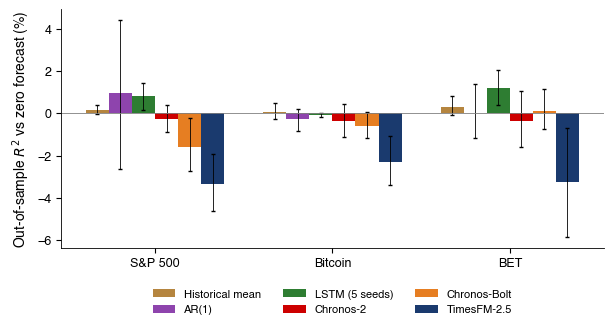

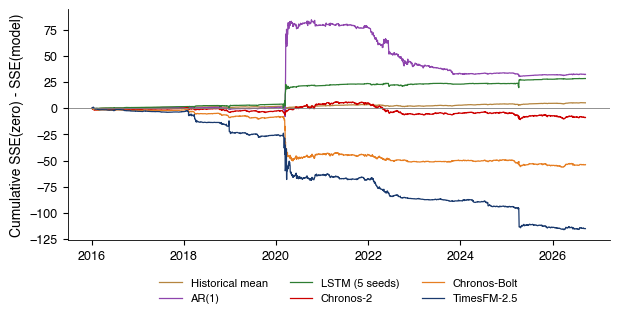

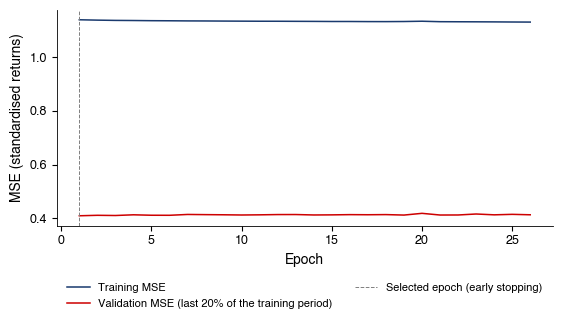

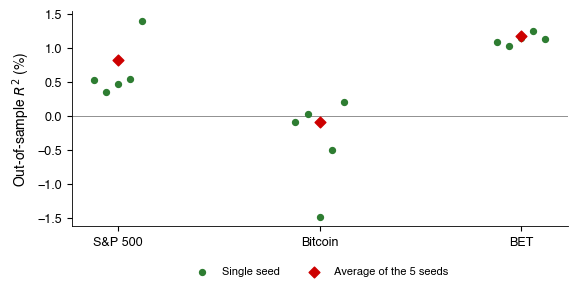

,sp500,btc,bet
Historical mean,0.148,0.073,0.302
AR(1),0.940,-0.279,-0.000
LSTM (5 seeds),0.824,-0.079,1.176
Chronos-2,-0.260,-0.346,-0.392
Chronos-Bolt,-1.575,-0.612,0.122
TimesFM-2.5,-3.355,-2.289,-3.268


In [11]:
def eval_returns():
    out, series = {}, {}
    for a in ASSETS:
        d = load_csv(f'ch14_returns_{a}.csv')
        y = d['y'].values
        post = d.index >= POST_FROM
        res = {'n': int(len(d)), 'start': str(d.index[0].date()), 'end': str(d.index[-1].date()),
               'n_post': int(post.sum()), 'sd': float(y.std())}
        for k in RET_MODELS:
            f = d[k].values
            e0, e1 = y ** 2, (y - f) ** 2
            lo, hi = block_bootstrap_ci(lambda yy, ff: r2_oos(yy, ff), [y, f], B=1000)
            dm = diebold_mariano(e1, e0)
            st = sign_test(y, f)
            res[k] = dict(r2=100 * r2_oos(y, f), lo=100 * lo, hi=100 * hi, dm=dm['DM'], p=dm['p'],
                          hit=100 * st['rate'], hit_p=st['p'], r2_post=100 * r2_oos(y[post], f[post]),
                          sd_f=float(f.std()))
        res['lstm_seeds'] = [100 * r2_oos(y, d[f'lstm_s{s}'].values) for s in range(5)]
        out[a] = res
        series[a] = d
    RES['ret'] = out
    return series


def fig_return_r2(series):
    R = RES['ret']
    keys = list(RET_MODELS)
    fig, ax = plt.subplots(figsize=(7.0, 3.1))
    w = 0.13
    x = np.arange(len(ASSETS))
    for j, k in enumerate(keys):
        v = np.array([R[a][k]['r2'] for a in ASSETS])
        lo = np.array([R[a][k]['lo'] for a in ASSETS])
        hi = np.array([R[a][k]['hi'] for a in ASSETS])
        ax.bar(x + (j - 2.5) * w, v, w, color=RET_COL[k], label=RET_MODELS[k])
        ax.errorbar(x + (j - 2.5) * w, v, yerr=[v - lo, hi - v], fmt='none', ecolor='black', lw=0.6, capsize=1.5)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xticks(x, [LABELS[a] for a in ASSETS])
    ax.set_ylabel(r'Out-of-sample $R^2$ vs zero forecast (%)')
    legend_outside_bottom(ax, ncol=3, y=-0.13)
    save_fig('ch14_return_r2')


def fig_cum_sse(series):
    d = series['sp500']
    y = d['y'].values
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    for k in RET_MODELS:
        c = np.cumsum(y ** 2 - (y - d[k].values) ** 2)
        ax.plot(d.index, c, color=RET_COL[k], lw=0.9, label=RET_MODELS[k])
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_ylabel('Cumulative SSE(zero) - SSE(model)')
    legend_outside_bottom(ax, ncol=3, y=-0.12)
    save_fig('ch14_cum_sse')


def fig_lstm_training():
    h = load_csv('ch14_lstm_hist_sp500_s0.csv').reset_index(drop=True)
    best = int(h['val'].idxmin())
    fig, ax = plt.subplots(figsize=(6.4, 2.8))
    ax.plot(h.index + 1, h['train'], color=MainBlue, label='Training MSE')
    ax.plot(h.index + 1, h['val'], color=IDAred, label='Validation MSE (last 20% of the training period)')
    ax.axvline(best + 1, color=Gray, ls='--', lw=0.7, label='Selected epoch (early stopping)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (standardised returns)')
    legend_outside_bottom(ax, ncol=2, y=-0.22)
    save_fig('ch14_lstm_training')
    RES['lstm_train'] = dict(epochs=int(len(h)), best=best + 1, train_best=float(h['train'][best]),
                             val_best=float(h['val'][best]), val_first=float(h['val'][0]))


def fig_lstm_seeds():
    R = RES['ret']
    fig, ax = plt.subplots(figsize=(6.4, 2.8))
    for i, a in enumerate(ASSETS):
        s = R[a]['lstm_seeds']
        ax.scatter(np.full(5, i) + np.linspace(-0.12, 0.12, 5), s, color=Forest, s=18, zorder=3,
                   label='Single seed' if i == 0 else None)
        ax.scatter([i], [R[a]['lstm']['r2']], color=IDAred, marker='D', s=30, zorder=4,
                   label='Average of the 5 seeds' if i == 0 else None)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xticks(range(3), [LABELS[a] for a in ASSETS])
    ax.set_ylabel(r'Out-of-sample $R^2$ (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch14_lstm_seeds')


ser = eval_returns()
fig_return_r2(ser)
fig_cum_sse(ser)
fig_lstm_training()
fig_lstm_seeds()
pd.DataFrame({a: {RET_MODELS[k]: RES['ret'][a][k]['r2'] for k in RET_MODELS} for a in ASSETS}).round(3)

## 7. Forecasting realised volatility (SPY)

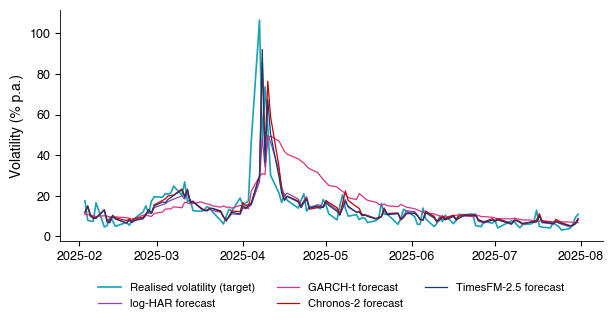

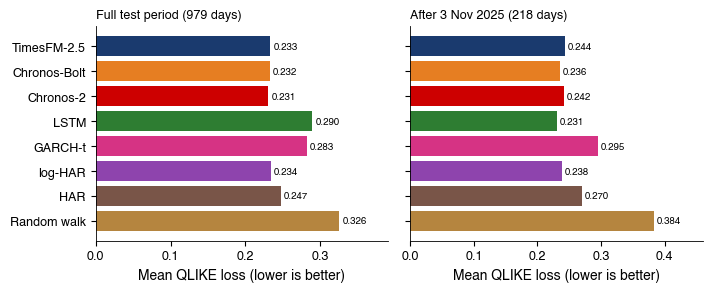

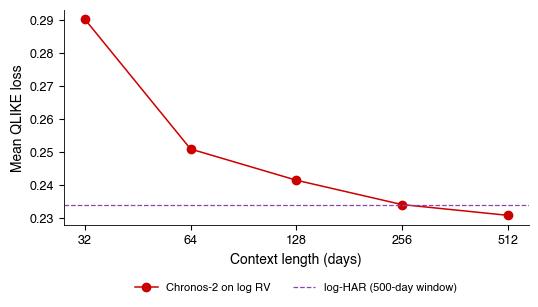

,qlike,dm,p,mcs,qlike_post,ratio
RW,0.3259,4.5259,0.0000,0.004,0.3838,1.0028
HAR,0.2475,1.2976,0.1944,0.260,0.2697,1.3620
logHAR,0.2338,NaN,NaN,0.947,0.2384,0.9341
GARCH-t,0.2826,3.4292,0.0006,0.032,0.2951,1.1070
LSTM,0.2895,1.8697,0.0615,0.193,0.2311,0.9308
Chronos-2,0.2308,-0.6177,0.5368,1.000,0.2423,1.0168
Chronos-Bolt,0.2324,-0.1808,0.8566,0.947,0.2359,0.9694
TimesFM-2.5,0.2335,-0.0773,0.9384,0.947,0.2438,0.9397


In [12]:
def eval_rv():
    d = load_csv('ch14_rv.csv')
    post = d.index >= POST_FROM
    L = pd.DataFrame({m: qlike(d['RV'], d[m]) for m in RV_MODELS})
    E = pd.DataFrame({m: (d['RV'] - d[m]) ** 2 for m in RV_MODELS})
    p_mcs = mcs(L)
    out = {'n': int(len(d)), 'start': str(d.index[0].date()), 'end': str(d.index[-1].date()),
           'n_post': int(post.sum()), 'rv_mean': float(d['RV'].mean()),
           'vol_mean': float(np.sqrt(252 * d['RV'].mean()))}
    for m in RV_MODELS:
        dm = diebold_mariano(L[m], L['logHAR']) if m != 'logHAR' else dict(DM=np.nan, p=np.nan)
        dmp = diebold_mariano(L[m][post], L['logHAR'][post]) if m != 'logHAR' else dict(DM=np.nan, p=np.nan)
        out[m] = dict(qlike=float(L[m].mean()), mse=float(E[m].mean()), dm=float(dm['DM']), p=float(dm['p']),
                      mcs=float(p_mcs[m]), qlike_post=float(L[m][post].mean()), dm_post=float(dmp['DM']),
                      p_post=float(dmp['p']), ratio=float(d[m].mean() / d['RV'].mean()))
    for m in ('Chronos-2', 'TimesFM-2.5'):
        lm = qlike(d['RV'], d[m + '|median'])
        out[m + '|median'] = dict(qlike=float(lm.mean()), ratio=float(d[m + '|median'].mean() / d['RV'].mean()),
                                  dm_vs_mean=float(diebold_mariano(lm, L[m])['DM']))
    c = load_csv('ch14_ctx.csv')
    out['ctx'] = {k: float(qlike(c['RV'], c[k]).mean()) for k in c.columns[1:]}
    p_post = mcs(L[post])
    for m in RV_MODELS:
        out[m]['mcs_post'] = float(p_post[m])
    RES['rv'] = out
    return d, L


def fig_rv_path(d):
    s = d.loc['2025-02-01':'2025-07-31']
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    ax.plot(s.index, np.sqrt(252 * s['RV']), color=Teal, lw=1.2, label='Realised volatility (target)')
    for m in ('logHAR', 'GARCH-t', 'Chronos-2', 'TimesFM-2.5'):
        ax.plot(s.index, np.sqrt(252 * s[m]), color=RV_COL[m], lw=0.9, label=RV_LBL[m] + ' forecast')
    ax.set_ylabel('Volatility (% p.a.)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    legend_outside_bottom(ax, ncol=3, y=-0.14)
    save_fig('ch14_rv_forecasts')
    RES['rv_path'] = dict(peak_day=str(s['RV'].idxmax().date()), peak_vol=float(np.sqrt(252 * s['RV'].max())))


def fig_qlike():
    R = RES['rv']
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), sharey=True)
    for ax, key, title in ((axes[0], 'qlike', f'Full test period ({R["n"]} days)'),
                           (axes[1], 'qlike_post', f'After 3 Nov 2025 ({R["n_post"]} days)')):
        v = [R[m][key] for m in RV_MODELS]
        ax.barh(range(len(RV_MODELS)), v, color=[RV_COL[m] for m in RV_MODELS])
        for i, m in enumerate(RV_MODELS):
            ax.text(v[i] + 0.004, i, f'{v[i]:.3f}', va='center', fontsize=7, color='black')
        ax.set_yticks(range(len(RV_MODELS)), [RV_LBL[m] for m in RV_MODELS])
        ax.invert_yaxis()
        ax.set_xlabel('Mean QLIKE loss (lower is better)')
        ax.set_title(title, fontsize=9, loc='left')
        ax.set_xlim(0, max(v) * 1.2)
    fig.tight_layout()
    save_fig('ch14_qlike')


def fig_context():
    R = RES['rv']
    Ls = sorted(int(k) for k in R['ctx'])
    fig, ax = plt.subplots(figsize=(6.0, 2.8))
    ax.plot(Ls, [R['ctx'][str(L)] for L in Ls], 'o-', color=IDAred, label='Chronos-2 on log RV')
    ax.axhline(R['logHAR']['qlike'], color=Purple, ls='--', lw=0.9, label='log-HAR (500-day window)')
    ax.set_xscale('log', base=2)
    ax.set_xticks(Ls, [str(L) for L in Ls])
    ax.set_xlabel('Context length (days)')
    ax.set_ylabel('Mean QLIKE loss')
    legend_outside_bottom(ax, ncol=2, y=-0.22)
    save_fig('ch14_context_length')


d, L = eval_rv()
fig_rv_path(d)
fig_qlike()
fig_context()
pd.DataFrame({m: RES['rv'][m] for m in RV_MODELS}).T[['qlike', 'dm', 'p', 'mcs', 'qlike_post', 'ratio']].round(4)

## 8. Tail risk: VaR 1% and ES 2.5%

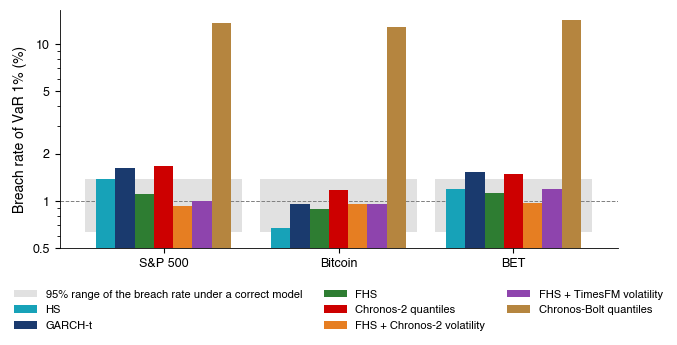

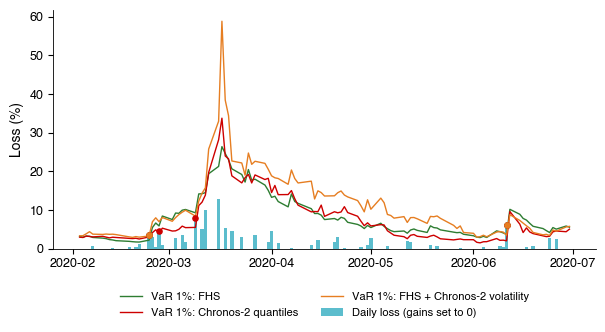

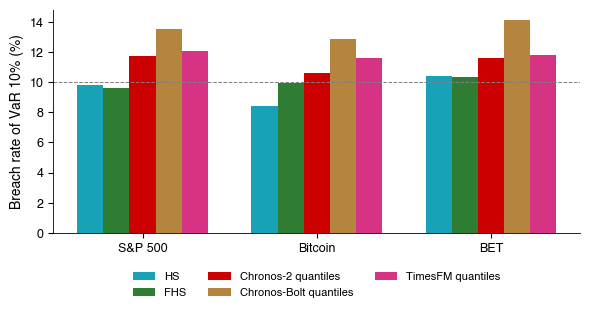

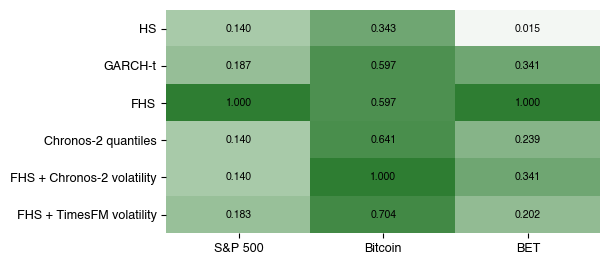

x    rate    p_uc   p_ind     fz0    mcs
sp500 HS       37.0  1.3739  0.0650  0.0014  1.3089  0.140
      GARCH-t  44.0  1.6339  0.0025  0.2049  1.0256  0.187
      FHS      30.0  1.1140  0.5593  0.0451  0.9987  1.000
      C2-raw   45.0  1.6710  0.0014  0.2226  1.1474  0.140
      C2-FHS   25.0  0.9283  0.7052  0.0209  1.0837  0.140
      TFM-FHS  27.0  1.0026  0.9892  0.0290  1.0590  0.183
btc   HS       19.0  0.6742  0.0647  0.6115  2.2367  0.343
      GARCH-t  27.0  0.9581  0.8220  0.2611  2.1923  0.597
      FHS      25.0  0.8872  0.5393  0.2199  2.1925  0.597
      C2-raw   33.0  1.1710  0.3743  0.4037  2.1814  0.641
      C2-FHS   27.0  0.9581  0.8220  0.0264  2.1509  1.000
      TFM-FHS  27.0  0.9581  0.8220  0.2611  2.1602  0.704
bet   HS       32.0  1.1963  0.3224  0.3994  1.2296  0.015
      GARCH-t  41.0  1.5327  0.0102  0.2585  1.0012  0.341
      FHS      30.0  1.1215  0.5356  0.4093  0.9628  1.000
      C2-raw   40.0  1.4953  0.0165  0.2704  1.0319  0.239
      C2-FHS   26.0  0.9720  0.8836  0.4749  1.0074  0.341
      TFM-FHS  32.0  1.1963  0.3224  0.3786  1.0268  0.202

In [13]:
def eval_risk():
    out, series = {}, {}
    for a in ASSETS:
        d = load_csv(f'ch14_risk_{a}.csv')
        L = -d['y'].values
        post = d.index >= POST_FROM
        res = {'n': int(len(d)), 'start': str(d.index[0].date()), 'n_post': int(post.sum())}
        fz = {}
        for m in RISK_MODELS:
            v1, v25, es = d[f'{m}|VaR1'].values, d[f'{m}|VaR2.5'].values, d[f'{m}|ES2.5'].values
            h = (L > v1).astype(int)
            k = kupiec(h, 0.01)
            c = christoffersen(h, 0.01)
            kp = kupiec(h[post], 0.01)
            fz[m] = fz0(L, v25, np.maximum(es, 1e-6))
            res[m] = dict(x=k['x'], rate=100 * k['rate'], p_uc=k['p'], p_ind=c['p_ind'], p_cc=c['p_cc'],
                          n11=c['n11'], x_post=kp['x'], rate_post=100 * kp['rate'], p_post=kp['p'],
                          fz0=float(fz[m].mean()), var_mean=float(v1.mean()), es_mean=float(es.mean()),
                          es_ratio=float(np.mean(es / v1)), x25=int(np.sum(L > v25)),
                          pin1=float(np.mean(pinball(-L, -v1, 0.01))))
        F = pd.DataFrame(fz)
        p = mcs(F)
        for m in RISK_MODELS:
            res[m]['mcs'] = float(p[m])
            dm = diebold_mariano(F[m], F['FHS']) if m != 'FHS' else dict(DM=np.nan, p=np.nan)
            res[m]['dm_fhs'] = float(dm['DM'])
            res[m]['p_dm_fhs'] = float(dm['p'])
        # cuantile directe la 1% pentru Bolt si TimesFM (limitate la decila 10%) si VaR 10%
        for fm in ('bolt', 'timesfm'):
            h = (L > d[f'{fm}-raw|VaR1'].values).astype(int)
            res[f'{fm}-raw'] = dict(rate=100 * h.mean(), x=int(h.sum()))
        v10 = {}
        for m, col in (('HS', 'HS|VaR10'), ('FHS', 'FHS|VaR10'), ('C2-raw', 'C2-raw|VaR10'),
                       ('bolt-raw', 'bolt-raw|VaR10'), ('timesfm-raw', 'timesfm-raw|VaR10')):
            h = (L > d[col].values).astype(int)
            k = kupiec(h, 0.10)
            c = christoffersen(h, 0.10)
            v10[m] = dict(rate=100 * k['rate'], p_uc=k['p'], p_ind=c['p_ind'],
                          pin=float(np.mean(pinball(-L, -d[col].values, 0.10))))
        res['v10'] = v10
        out[a] = res
        series[a] = d
    RES['risk'] = out
    return series


def fig_breaches():
    R = RES['risk']
    models = RISK_MODELS + ['bolt-raw']
    fig, ax = plt.subplots(figsize=(7.2, 3.1))
    w = 0.11
    x = np.arange(len(ASSETS))
    for i, a in enumerate(ASSETS):
        n = R[a]['n']
        lo, hi = stats.binom.ppf([0.025, 0.975], n, 0.01) / n * 100
        ax.fill_between([i - 0.45, i + 0.45], lo, hi, color=LightGray, alpha=0.8, lw=0, zorder=0,
                        label='95% range of the breach rate under a correct model' if i == 0 else None)
    for j, m in enumerate(models):
        v = [R[a][m]['rate'] for a in ASSETS]
        ax.bar(x + (j - (len(models) - 1) / 2) * w, v, w, color=RISK_COL[m], label=RISK_LBL[m], zorder=3)
    ax.axhline(1, color=Gray, ls='--', lw=0.7)
    ax.set_yscale('log')
    ax.set_yticks([0.5, 1, 2, 5, 10], ['0.5', '1', '2', '5', '10'])
    ax.set_xticks(x, [LABELS[a] for a in ASSETS])
    ax.set_ylabel('Breach rate of VaR 1% (%)')
    legend_outside_bottom(ax, ncol=3, y=-0.13)
    save_fig('ch14_breach_rates')


def fig_var_path(series):
    d = series['sp500'].loc['2020-02-01':'2020-06-30']
    L = -d['y']
    fig, ax = plt.subplots(figsize=(7.0, 3.1))
    ax.bar(d.index, L.clip(lower=0), width=1.0, color=Teal, alpha=0.7, label='Daily loss (gains set to 0)')
    for m in ('FHS', 'C2-raw', 'C2-FHS'):
        ax.plot(d.index, d[f'{m}|VaR1'], color=RISK_COL[m], lw=1.0, label=f'VaR 1%: {RISK_LBL[m]}')
        hit = L > d[f'{m}|VaR1']
        ax.scatter(d.index[hit], L[hit], color=RISK_COL[m], s=14, zorder=3)
    ax.set_ylabel('Loss (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch14_var_path')
    RES['covid'] = {m: int(np.sum(L > d[f'{m}|VaR1'])) for m in RISK_MODELS}
    RES['covid']['T'] = int(len(d))
    RES['covid']['maxloss'] = float(L.max())
    for m in ('FHS', 'C2-raw', 'C2-FHS'):
        RES['covid'][m + '|max'] = float(d[f'{m}|VaR1'].max())


def fig_var10():
    R = RES['risk']
    models = ['HS', 'FHS', 'C2-raw', 'bolt-raw', 'timesfm-raw']
    fig, ax = plt.subplots(figsize=(6.8, 2.9))
    w = 0.15
    x = np.arange(len(ASSETS))
    for j, m in enumerate(models):
        v = [R[a]['v10'][m]['rate'] for a in ASSETS]
        ax.bar(x + (j - 2) * w, v, w, color=RISK_COL[m], label=RISK_LBL[m])
    ax.axhline(10, color=Gray, ls='--', lw=0.7)
    ax.set_xticks(x, [LABELS[a] for a in ASSETS])
    ax.set_ylabel('Breach rate of VaR 10% (%)')
    legend_outside_bottom(ax, ncol=3, y=-0.13)
    save_fig('ch14_var10')


def fig_mcs():
    R = RES['risk']
    P = pd.DataFrame({LABELS[a]: [R[a][m]['mcs'] for m in RISK_MODELS] for a in ASSETS},
                     index=[RISK_LBL[m] for m in RISK_MODELS])
    Z = np.log10(np.clip(P.values.astype(float), 1e-4, 1))
    fig, ax = plt.subplots(figsize=(5.6, 2.9))
    ax.imshow(Z, cmap=PV_CMAP, vmin=-4, vmax=0, aspect='auto')
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            v = P.values[i, j]
            ax.text(j, i, '<0.001' if v < 0.001 else f'{v:.3f}', ha='center', va='center', fontsize=7.5, color='black')
    ax.set_xticks(range(P.shape[1]), P.columns)
    ax.set_yticks(range(P.shape[0]), P.index)
    for s in ax.spines.values():
        s.set_visible(False)
    save_fig('ch14_mcs')


rs = eval_risk()
fig_breaches()
fig_var_path(rs)
fig_var10()
fig_mcs()
pd.DataFrame({(a, m): {k: RES['risk'][a][m][k] for k in ('x', 'rate', 'p_uc', 'p_ind', 'fz0', 'mcs')} for a in ASSETS for m in RISK_MODELS}).T.round(4)

## Summary

- Returns: no deep or foundation model beats the zero forecast significantly.
- Volatility: zero-shot foundation models are as accurate as log-HAR, not better.
- Tail risk: raw quantiles of foundation models are too narrow; used as volatility filters inside FHS they give correct coverage, but FHS with GARCH remains the reference.